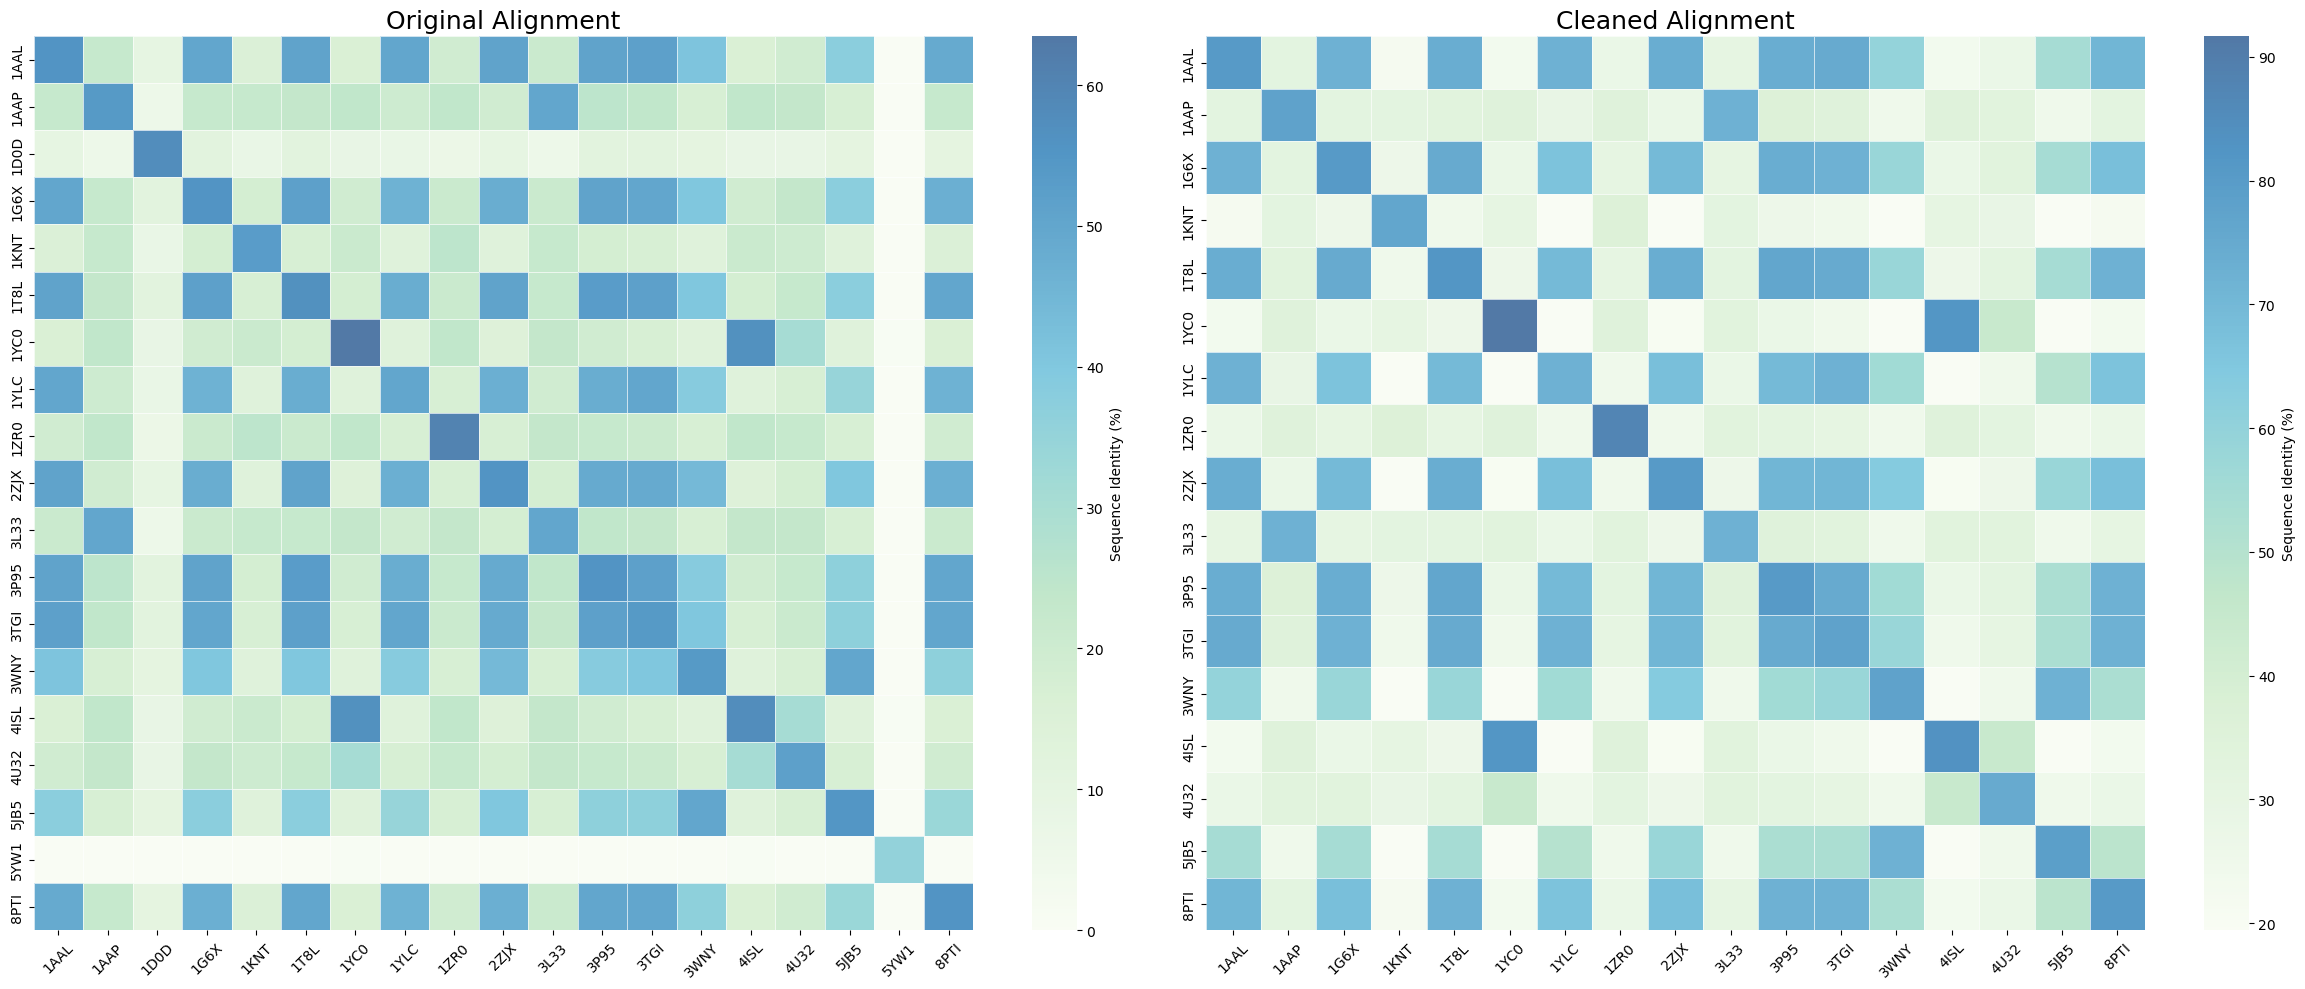

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Improved Parser to handle potential formatting quirks in .ali files
def get_identity_df(file_path):
    sequences = {}
    current_id = None
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                # Shorten IDs for the plot labels
                current_id = line[1:5].split('.')[0]
                sequences[current_id] = ""
            elif current_id and line and not line.startswith('/') and line != '*':
                sequences[current_id] += line
    
    ids = list(sequences.keys())
    seq_list = list(sequences.values())
    n = len(ids)
    matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            s1, s2 = seq_list[i], seq_list[j]
            # Standard identity calculation
            matches = sum(1 for a, b in zip(s1, s2) if a == b and a != '-')
            # We divide by the alignment length to show how much 'gap' noise affects the score
            matrix[i, j] = (matches / len(s1)) * 100
            
    return pd.DataFrame(matrix, index=ids, columns=ids)

# 2. Setup the Visualization with two subplots
files_to_process = [
    ("kunitz.ali", "Original Alignment"),
    ("kunitz_clean.ali", "Cleaned Alignment")
]

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

for i, (file_path, title) in enumerate(files_to_process):
    try:
        df = get_identity_df(file_path)
        
        sns.heatmap(
            df, 
            annot=False, 
            cmap='GnBu', 
            alpha=0.7, 
            linewidths=.5,
            cbar_kws={'label': 'Sequence Identity (%)'},
            ax=axes[i]
        )
        axes[i].set_title(title, fontsize=18)
        axes[i].tick_params(axis='x', rotation=45)
        
    except FileNotFoundError:
        axes[i].text(0.5, 0.5, f"File Not Found:\n{file_path}", 
                     ha='center', va='center', fontsize=14)
        axes[i].set_title(title)

plt.tight_layout()
plt.savefig("alignment_comparison_heatmaps.png",)
plt.show()